In [39]:
from matplotlib import pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import joblib
import gc

plt.style.use('ggplot')

In [40]:
news_real_labels = ['reliable']
news_fake_labels = ['bias','fake','unreliable','rumor','conspiracy','clickbait','junksci','satire','political','hate']

df_news = (
    pl.scan_csv('data/995,000_rows.csv')
    .select([
        pl.col('type').alias('isfake'),
        pl.col('content')
    ])
    .filter(pl.col('isfake').is_in(news_real_labels + news_fake_labels))
    .with_columns(
        pl.when(pl.col('isfake').is_in(news_fake_labels))
        .then(1)
        .otherwise(0)
        .alias('isfake')
    )
    .collect()
)

In [3]:
liar_real_labels = ['mostly-true', 'true']
liar_fake_labels = ['false','pants-fire', 'half-true', 'barely-true']

df_liar = (
    pl.scan_csv('liar_dataset/aggregated.csv')
    .select([
        pl.col('isfake'),
        pl.col('title').alias('content')
    ])
    .filter(pl.col('isfake').is_in(liar_real_labels + liar_fake_labels))
    .with_columns(
        pl.when(pl.col('isfake').is_in(liar_fake_labels))
        .then(1)
        .otherwise(0)
        .alias('isfake')
    )
    .collect()
)

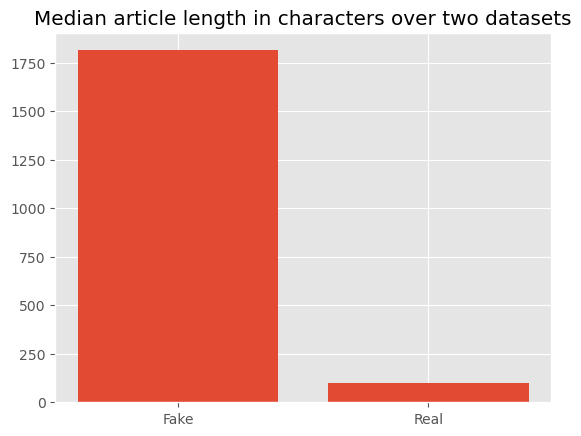

In [ ]:
# Barplot over article counts

x_lab = ['FakeNewsCorpus', 'Liar Dataset']
# Average length of articles
news_med = (df_news['content']).str.len_chars().median()
liar_med = (df_liar['content']).str.len_chars().median()

print('Median of article length in\n:'\
      f'FakeNewsCorpus: {news_med}, Liar dataset: {liar_med}')

plt.bar(x_lab, [news_med, liar_med])
plt.title('Median article length in characters over two datasets')
plt.savefig('data/dataset_len_avg.png')
plt.show()

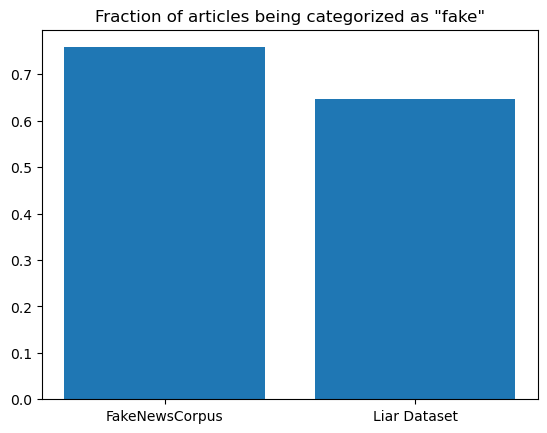

In [5]:
# Fraction of articles being classified as fake
news_frac = sum(df_news['isfake']) / len(df_news)
liar_frac = sum(df_liar['isfake']) / len(df_liar)

plt.bar(x_lab, [news_frac, liar_frac])
plt.title('Fraction of articles being categorized as "fake"')
plt.show()

In [6]:
[news_frac, liar_frac]

[0.7581397819358423, 0.6476384110103222]

In [7]:
gc.collect()

4848

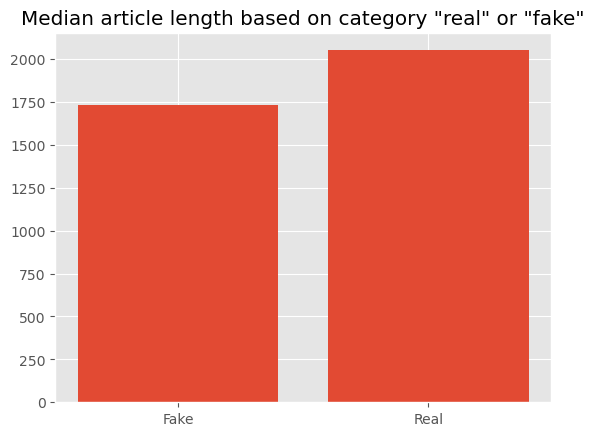

In [ ]:
# Testing difference in length based on real or fake categori.

df_fake = df_news.filter(pl.col('isfake') == 1)
df_real = df_news.filter(pl.col('isfake') == 0)

fake_med = (df_fake['content']).str.len_chars().median()
real_med = (df_real['content']).str.len_chars().median()

x_lab = ['Fake', 'Real']

plt.bar(x_lab, [fake_med, real_med])
plt.title('Median article length based on category "real" or "fake"')
plt.savefig('data/label_len_avg.png')
plt.show()

In [9]:
del df_fake, df_real
gc.collect()

2570

In [4]:
df_liar = df_liar.with_columns(pl.col('content').map_elements(lambda x : len(x)).alias('length'))
df_news = df_news.with_columns(pl.col('content').map_elements(lambda x : len(x)).alias('length'))

In [24]:
# Median and quartile lengths for the Liar dataset article lengths
quantiles = [
    df_liar.select(pl.col('length')).min().to_numpy()[0][0],
    df_liar.select(pl.col('length')).quantile(0.25).to_numpy()[0][0],
    df_liar.select(pl.col('length')).quantile(0.5).to_numpy()[0][0],
    df_liar.select(pl.col('length')).quantile(0.75).to_numpy()[0][0],
    df_liar.select(pl.col('length')).max().to_numpy()[0][0]
]
print(f'1st quantile: {quantiles[1]}, median: {quantiles[2]}, 3rd quantile: {quantiles[3]}')

1st quantile: 73.0, median: 99.0, 3rd quantile: 133.0


In [33]:
# Now calculate the probability of an article in FakeNewsCorpus train set 
# being fake if restricted to each of the quartiles as max length.

# Dataframes of articles restricted to a given max length
q_dfs = [df_news.filter(pl.col('length') <= q) for q in quantiles]

# Probabilities of articles in the dataframes being fake.
# Account for devision by zero possibility.
probs = [
    len(q_df.filter(pl.col('isfake') == 1)) / len(q_df) 
    if len(q_df) > 0 else 0 for q_df in q_dfs
]

print(
    'Probability of an article in FakeNewsCorpus being fake given that its\n'\
    'length is smaller than the specified length quantiles from the Liar dataset:\n'\
    f'Min: {probs[0]:.3f}\n'\
    f'1st quantile: {probs[1]:.3f}\n'\
    f'Median: {probs[2]:.3f}\n'\
    f'3rd quantile: {probs[3]:.3f}\n'\
    f'Max: {probs[4]:.3f}'\
)

Probability of an article in FakeNewsCorpus being fake given that its
length is smaller than the specified length quantiles from the Liar dataset:
Min: 0.000
1st quantile: 0.799
Median: 0.879
3rd quantile: 0.931
Max: 0.784


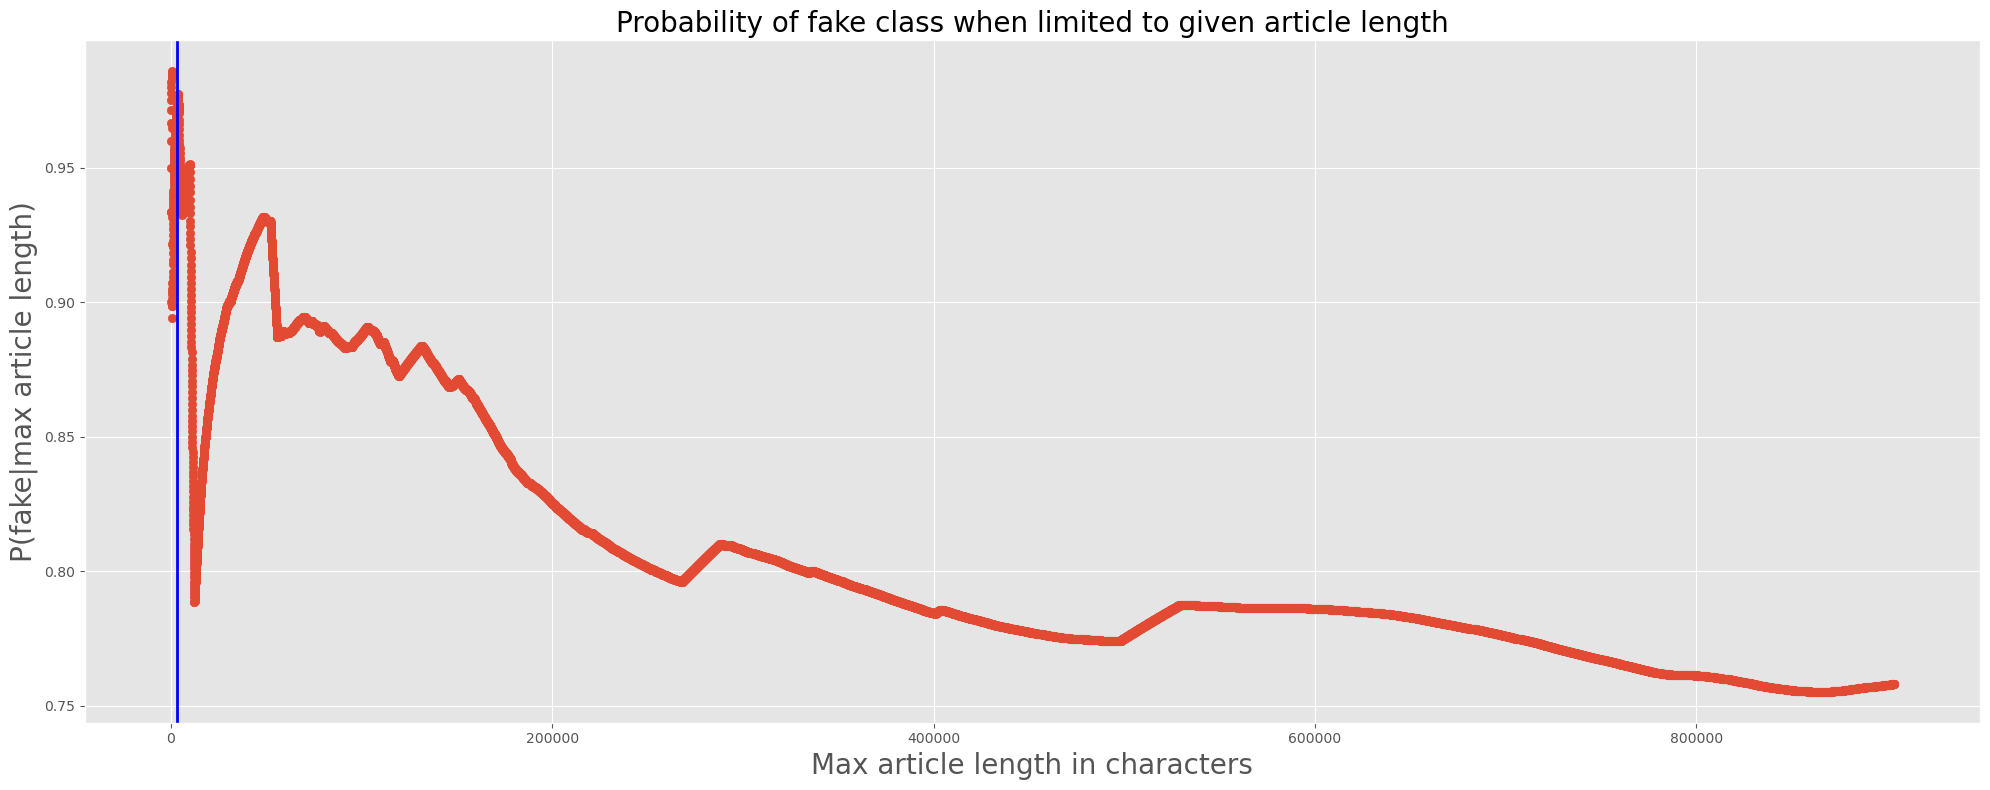

In [38]:
# Creating plot of the relationship between fake probability and article length
df_sorted = df_news.sort('length')

x_vals = []
y_vals = []

sum_fake = 0
num_articles = 0
step_size = 30

i = 0
n = len(df_sorted)
while i <= n:
    df_slice = df_sorted[i: i + step_size]

    sum_fake += len(df_slice.filter(pl.col('isfake') == 1))
    num_articles += len(df_slice)

    x_vals.append(i)
    y_vals.append(sum_fake / num_articles)

    i += min(step_size, n)


plt.figure(figsize=(20, 8))
plt.scatter(x_vals, y_vals, marker='o')
plt.axvline(x=quantiles[4], color='blue', linestyle='-', linewidth=2)
plt.title('Probability of fake class when limited to given article length', fontsize=20)
plt.xlabel('Max article length in characters', fontsize=20)
plt.ylabel('P(fake|max article length)', fontsize=20)
plt.tight_layout()
plt.savefig('plots/fake_prob_vs_len.png')
plt.show()

In [23]:
# Last year updated
max_year = (
    df_news.select(
        pl.col("updated_at")
        .str.to_datetime()
        .dt.year()              
        .max()                  
    )
    .item()
)
max_year

2018